In [315]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd

%config InlineBackend.figure_format = 'svg'

**Spotify Dataset**

In [316]:
# Open file and filter to only spotify related columns
with open('spotify.csv') as file:   
    spotify_tracks = pd.read_csv('spotify.csv', encoding='unicode_escape')

spotify = spotify_tracks[['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC',
       'All Time Rank', 'Track Score', 'Spotify Streams',
       'Spotify Playlist Count', 'Spotify Playlist Reach',
       'Spotify Popularity']]

spotify.head()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",92.0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",92.0
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",92.0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",85.0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",88.0


In [317]:
spotify.tail()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity
4595,For the Last Time,For the Last Time,$uicideboy$,9/5/2017,QM8DG1703420,"4,585",19.4,"305,049,963","65,770","5,103,054",71.0
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,"52,282,360","4,602","1,449,767",56.0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,"189,972,685","72,066","6,704,802",65.0
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/8/2016,INY091600067,"4,591",19.4,"145,467,020","14,037","7,387,064",66.0
4599,Me Acostumbre (feat. Bad Bunny),Me Acostumbre (feat. Bad Bunny),Arcï¿½ï¿½,4/11/2017,USB271700107,"4,593",19.4,"255,740,653","32,138","14,066,526",64.0


**Clean Data**

In [318]:
# Change spotify streams, playlist count, playlist reach, all time rank to int
spotify['Spotify Streams'] = spotify['Spotify Streams'].str.replace(',', '')
spotify['Spotify Streams'] = spotify['Spotify Streams'].astype('Int64')

spotify['Spotify Playlist Count'] = spotify['Spotify Playlist Count'].str.replace(',', '')
spotify['Spotify Playlist Count'] = spotify['Spotify Playlist Count'].astype('Int64')

spotify['Spotify Playlist Reach'] = spotify['Spotify Playlist Reach'].str.replace(',', '')
spotify['Spotify Playlist Reach'] = spotify['Spotify Playlist Reach'].astype('Int64')

spotify['All Time Rank'] = spotify['All Time Rank'].str.replace(',', '')
spotify['All Time Rank'] = spotify['All Time Rank'].astype('Int64')

In [319]:
# Change release date column to date format

spotify['Release Date'] = pd.to_datetime(spotify['Release Date'], format='mixed')


In [320]:
spotify.isna().sum()

Track                       0
Album Name                  0
Artist                      5
Release Date                0
ISRC                        0
All Time Rank               0
Track Score                 0
Spotify Streams           113
Spotify Playlist Count     70
Spotify Playlist Reach     72
Spotify Popularity        804
dtype: int64

In [321]:
# Remove rows less than 5% of total rows

cols_to_drop = [col for col in spotify.columns if 0 < spotify[col].isnull().sum() < len(spotify) * 0.05]
print(cols_to_drop)

spotify = spotify.dropna(subset=cols_to_drop)

['Artist', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach']


In [322]:
# Change all null values from 'Spotify Popularity' to the median because of large gap between min and max value

spotify['Spotify Popularity'] = np.where((spotify['Spotify Popularity'].isna()), 
                                         spotify['Spotify Popularity'].median(), spotify['Spotify Popularity'] )



**Data Insights**

In [323]:
# Are songs that are popular on spotify considered good tracks? (Track Score Vs. Spotify Popularity)
fig, ax = plt.subplots()

# Create scatter plot
scatter = ax.scatter(x=spotify['Spotify Popularity'], y=spotify['Track Score'], 
        #  Size is scaled by popularity score squared for enhanced visibility
           s=((spotify['Spotify Popularity'] / 10) ** 2), 
           c=spotify['Spotify Popularity'], cmap='viridis', alpha=0.4)

# Set labels
ax.set_xlabel('Popularity Rating', fontsize=12, labelpad=10)
ax.set_ylabel('Track Score', fontsize=12, labelpad=10)
ax.set_title('Spotify Popularity vs. Track Score', fontsize=14, fontweight='bold', pad=15)

# Create grid
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add colorbar
fig.colorbar(scatter, ax=ax, label='Popularity Color Scale')

plt.tight_layout()
plt.show()

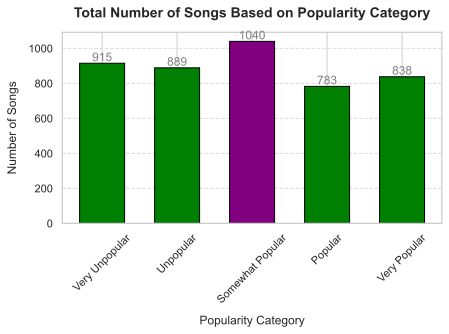

In [324]:
fig, ax = plt.subplots()

# Create categorical values from Spotify Popularity, determining popularity rating
spotify['Popularity Rating'] = pd.qcut(spotify['Spotify Popularity'], 5, labels=['Very Unpopular', 'Unpopular', 'Somewhat Popular', 'Popular', 'Very Popular'])
spotify['Popularity Rating'] = spotify['Popularity Rating'].astype('category')

# Order categories
spotify['Popularity Rating'] = spotify['Popularity Rating'].cat.reorder_categories(['Very Unpopular', 'Unpopular', 'Somewhat Popular', 'Popular', 'Very Popular'], ordered=True)

# Get counts and create a color list
counts = spotify['Popularity Rating'].value_counts(sort = False)
colors = ['Green' if counts.index[i] != 'Somewhat Popular' else 'Purple' for i in range(len(counts))]

# Create bar chart and pass in color list that highlights the highest value
plt.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.6)

# Annotate each bar with its count
for i in range(len(counts)):
    ax.annotate(f'{counts.values[i]}', xy=(counts.index[i], counts.values[i] + 30), va='center', ha='center', color='Gray')

# Set labels
ax.set_title('Total Number of Songs Based on Popularity Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Popularity Category', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Songs', fontsize=12, labelpad=10)

# Create grid
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Rotate x ticks
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

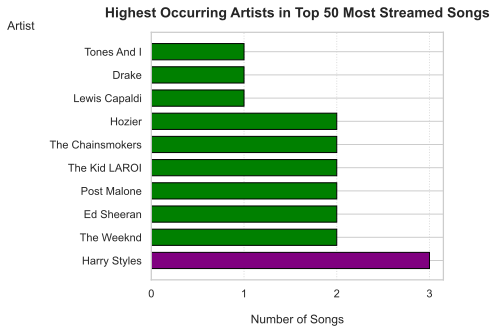

In [325]:
# Which 10 artists occurred the most in the top 50 most streamed songs
fig, ax = plt.subplots()

# Sort spotify streams from highest to lowest and get counts by artist
spot_streams = spotify.sort_values(by='Spotify Streams', ascending=False).head(25)
spot_counts = spot_streams['Artist'].value_counts()

# Create custom color list for most recurring artist
colors = ['Green' if spot_counts.index[i] != 'Harry Styles' else 'Purple' for i in range(len(spot_counts))]

# Create horizontal bar chart for the top 10
ax.barh(spot_counts.index[0:10], spot_counts.values[0:10], height=0.7, edgecolor='black', color=colors)

# Adjust x ticks
ax.set_xticks([0, 1, 2, 3])

# Create grid
ax.xaxis.grid(visible=True, linestyle=':', alpha=0.7)


# Set labels
ax.set_title('Highest Occurring Artists in Top 50 Most Streamed Songs', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Artist', fontsize=12, labelpad=15, loc='top', rotation=0)
ax.set_xlabel('Number of Songs', fontsize=12, labelpad=15)

plt.tight_layout()
plt.show()

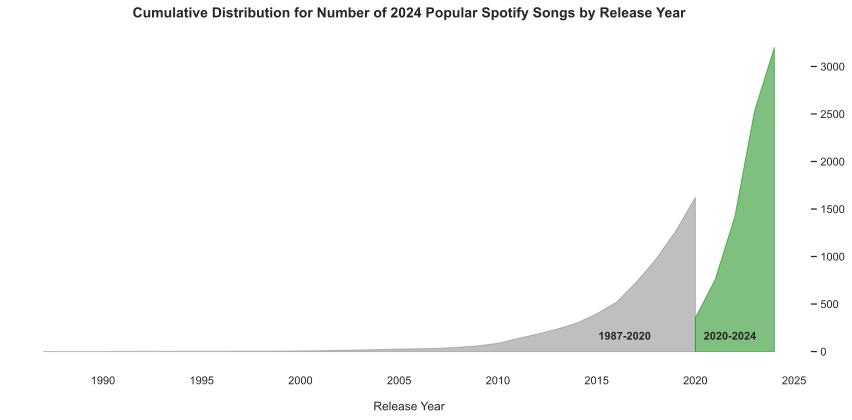

In [326]:
# Make a cumulative graph showcasing number of songs that were released before 2020, and after 2020
fig, ax = plt.subplots(figsize=(12,6))

# Create column for year
spotify['Release Year'] = spotify['Release Date'].dt.year

# Found 1987 as the earliest date
spotify.describe()

# Filter dataset for songs released between 1987 and 2020, and for songs released from 2020 to 2024
df_1987_2020 = spotify[spotify['Release Year'].between(1987, 2020)]

df_2020_2024 = spotify[spotify['Release Year'].between(2020, 2024)]

# Count number of songs released within each time period
count_1987_2020 = len(df_1987_2020)
count_2020_2024 = len(df_2020_2024)

# Calculate ratio of releases between time periods
ratio_1987_2020 = count_1987_2020 / (count_1987_2020 + count_2020_2024)
ratio_2020_2024 = count_2020_2024 / (count_1987_2020 + count_2020_2024)

# Group by the year of release and get total amount of songs released per year
year_count_1987_2020 = df_1987_2020.groupby('Release Year').size().cumsum()
year_count_2020_2024 = df_2020_2024.groupby('Release Year').size().cumsum()

# Plot graph
ax.fill_between(year_count_1987_2020.index, year_count_1987_2020, color='Gray', alpha=0.5, label='1987-2020')
ax.fill_between(year_count_2020_2024.index, year_count_2020_2024, color='Green', alpha=0.5, label='2020-2024')

ax.set_title('Cumulative Distribution for Number of 2024 Popular Spotify Songs by Release Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Release Year', fontsize=12, labelpad=15)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.yaxis.tick_right()

fig.text(0.7, 0.2, '1987-2020', fontweight='bold', fontsize=11)
fig.text(0.822, 0.2, '2020-2024', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()



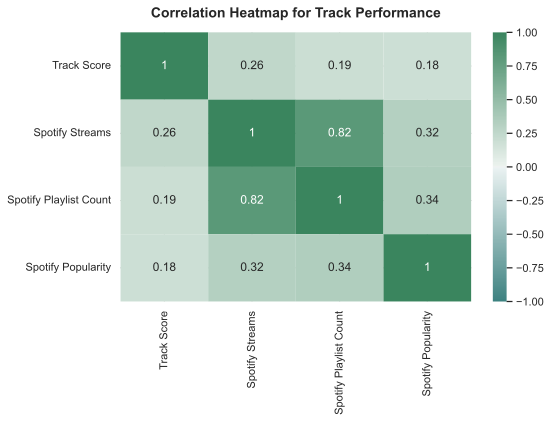

In [327]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))

# Get correlation values for certain columns
spot_corr = spotify[['Track Score', 'Spotify Streams',
       'Spotify Playlist Count',
       'Spotify Popularity']].corr(numeric_only=True)

# Create green diverging palette in order to highlight higher correlations
cmap = sns.diverging_palette(190, 145, as_cmap=True)

# Create heatmap
sns.heatmap(spot_corr, annot=True, vmin=-1, vmax=1, cmap=cmap)

# Set title
plt.title('Correlation Heatmap for Track Performance', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [328]:
# Spotify Playist Count vs Spotify Streams, log-scaled

fig, ax = plt.subplots(figsize=(7, 5))

# Create colormap
cmap = sns.cubehelix_palette(start=2, rot=0, dark=0, light=.95, reverse=True, as_cmap=True)

# Create scatter plot and scale by log to accurately display correlation
ax.scatter(y=spotify['Spotify Streams'], x=spotify['Spotify Playlist Count'], 
           c=np.log(spotify['Spotify Streams']), cmap=cmap,
           s=np.log(spotify['Spotify Streams']), alpha=0.6)

plt.xscale('log')
plt.yscale('log')

# Set labels
ax.set_ylabel('Spotify Streams (Log-Scaled)', labelpad=15, fontsize=12)
ax.set_xlabel('Spotify Playlist Count (Log-Scaled)', labelpad=15, fontsize=12)
ax.set_title('Playlist Count vs. Total Streams (Log-Scaled)', fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

[]

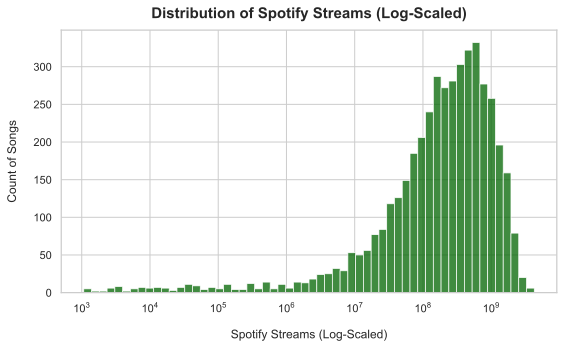

In [329]:
# Spotify Streams Distribution
plt.figure(figsize=(8, 5))

# Create a histogram that is log-scaled
ax = sns.histplot(data=spotify['Spotify Streams'], log_scale=True, color='darkgreen')

# Set labels
ax.set_xlabel('Spotify Streams (Log-Scaled)', fontsize=12, labelpad=15)
ax.set_ylabel('Count of Songs', fontsize=12, labelpad=15)
ax.set_title('Distribution of Spotify Streams (Log-Scaled)', fontsize=15, fontweight='bold', pad=12)

plt.tight_layout()
plt.plot()

**Youtube Dataset**

In [330]:
# Create a YouTube dataset by subsetting the correct variables
youtube = spotify_tracks[['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC',
       'All Time Rank', 'Track Score', 'YouTube Views', 'YouTube Likes']]
       
youtube.head()


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,YouTube Views,YouTube Likes
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"84,274,754","1,713,126"
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"116,347,040","3,486,739"
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"122,599,116","2,228,730"
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"1,096,100,899","10,629,796"
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"77,373,957","3,670,188"


**Clean Data**

In [331]:
youtube.isna().sum()

Track              0
Album Name         0
Artist             5
Release Date       0
ISRC               0
All Time Rank      0
Track Score        0
YouTube Views    308
YouTube Likes    315
dtype: int64

In [332]:
youtube.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Track          4600 non-null   str    
 1   Album Name     4600 non-null   str    
 2   Artist         4595 non-null   str    
 3   Release Date   4600 non-null   str    
 4   ISRC           4600 non-null   str    
 5   All Time Rank  4600 non-null   str    
 6   Track Score    4600 non-null   float64
 7   YouTube Views  4292 non-null   str    
 8   YouTube Likes  4285 non-null   str    
dtypes: float64(1), str(8)
memory usage: 323.6 KB


In [333]:
# Change Youtube views and likes into integers
youtube['YouTube Views'] = youtube['YouTube Views'].str.replace(',', '')
youtube['YouTube Likes'] = youtube['YouTube Likes'].str.replace(',', '')

youtube['YouTube Views'] = youtube['YouTube Views'].astype('Int64')
youtube['YouTube Likes'] = youtube['YouTube Likes'].astype('Int64')

In [334]:
# Fill up missing values with the value before itself
youtube.bfill(limit=2, inplace=True)

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,YouTube Views,YouTube Likes
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,84274754,1713126
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,116347040,3486739
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,122599116,2228730
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,1096100899,10629796
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,77373957,3670188
...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,9/5/2017,QM8DG1703420,"4,585",19.4,149247747,1397590
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,943920245,5347766
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,201027333,1081402
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/8/2016,INY091600067,"4,591",19.4,1118595159,3868828


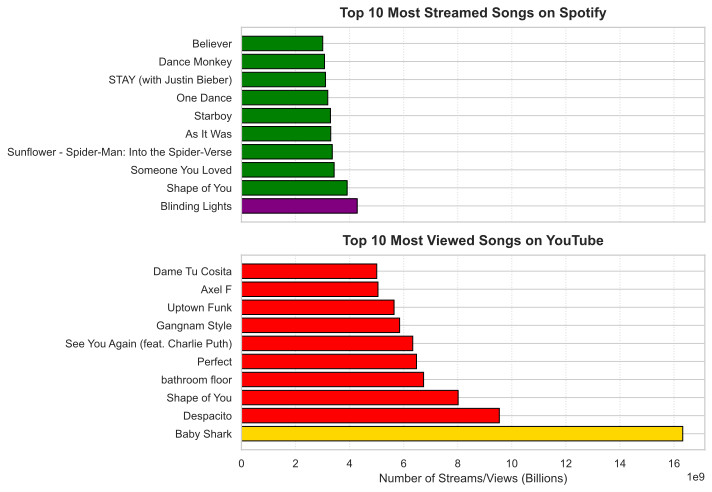

In [335]:
# Top 10 Tracks by Spotify Streams and Youtube Views

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 7))

# Get top 10 tracks/videos from Spotify and Youtube
top_10_spotify = spotify.sort_values('Spotify Streams', ascending=False).drop_duplicates(subset='Track').head(10)
top_10_youtube = youtube.sort_values('YouTube Views', ascending=False).drop_duplicates(subset='Track').head(10)
top_10_youtube.loc[top_10_youtube['Track'] == 'Gangnam Style (ï¿½ï¿½ï¿½ï¿½ï¿½ï', 'Track'] = 'Gangnam Style'

# Adjust colors to highight top track/video
spot_color = ['Green' if i != 'Blinding Lights' else 'Purple' for i in top_10_spotify['Track']]
yt_color = ['Red' if i != 'Baby Shark' else 'Gold' for i in top_10_youtube['Track']]

# Create two bar charts on the same figure
ax[0].barh(top_10_spotify['Track'], top_10_spotify['Spotify Streams'], color=spot_color, edgecolor='black')
ax[1].barh(top_10_youtube['Track'], top_10_youtube['YouTube Views'], color=yt_color, edgecolor='black')

# Set title and labels
ax[0].set_title('Top 10 Most Streamed Songs on Spotify', fontsize = 14, pad=10, fontweight='bold')
ax[1].set_title('Top 10 Most Viewed Songs on YouTube', fontsize = 14, pad=10, fontweight='bold')

ax[1].set_xlabel('Number of Streams/Views (Billions)', fontsize=12)

# Adjust grid
ax[0].xaxis.grid(visible=True, linestyle=':', alpha=0.7)
ax[1].xaxis.grid(visible=True, linestyle=':', alpha=0.7)

# Show xticks in Billions
plt.ticklabel_format(axis='x', style='sci', scilimits=(9, 9))

plt.tight_layout()
plt.show()
